# SOAL 2 : Audit Dataset, Preprocessing, dan Desain Data Pipeline
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid")
print("Library berhasil diimpor!")

Library berhasil diimpor!


In [4]:
# Membaca dataset
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

# Menampilkan 5 data teratas
print(f"Dataset berhasil dimuat! Dimensi awal: {df.shape[0]} baris, {df.shape[1]} kolom.")
df.head()

Dataset berhasil dimuat! Dimensi awal: 2111 baris, 17 kolom.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Audit Data

---



1. Tipe Data & Informasi Kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF

/tmp/ipykernel_5669/331000239.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='NObeyesdad', data=df, order=df['NObeyesdad'].value_counts().index, palette='viridis')


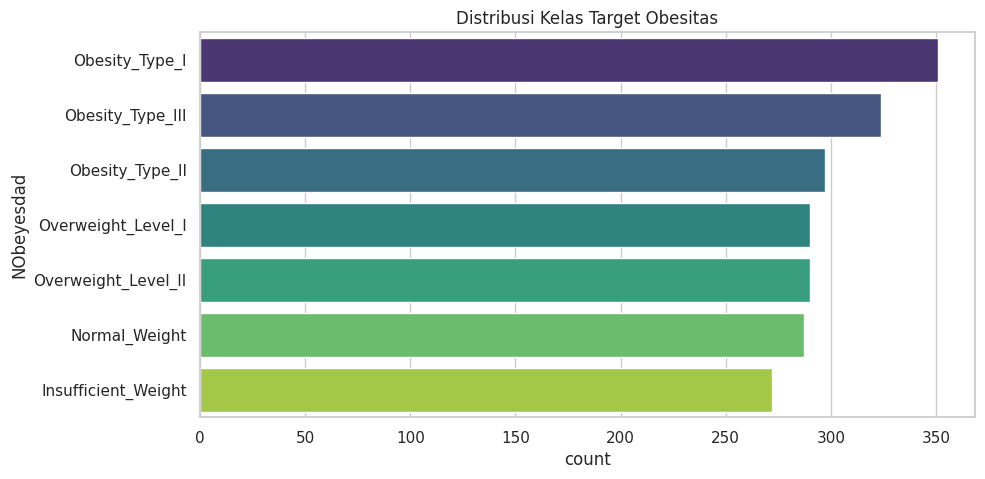

In [6]:
print("1. Tipe Data & Informasi Kolom")
print(df.info())

print("\n2. Pengecekan Missing Values")
print(df.isnull().sum())

print("\n3. Pengecekan Data Duplikat")
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat yang ditemukan: {duplicate_count}")

print("\n4. Distribusi Kelas Target")
print(df['NObeyesdad'].value_counts())

# Menampilkan grafik
plt.figure(figsize=(10, 5))
sns.countplot(y='NObeyesdad', data=df, order=df['NObeyesdad'].value_counts().index, palette='viridis')
plt.title('Distribusi Kelas Target Obesitas')
plt.show()

## Pembersihan Data & Data Splitting

---



In [7]:
# 1. Menghapus data duplikat
df_cleaned = df.drop_duplicates()
print(f"Dimensi setelah duplikat dihapus: {df_cleaned.shape[0]} baris\n")

# 2. Memisahkan Fitur (X) dan Target (y)
X = df_cleaned.drop(columns=['NObeyesdad'])
y = df_cleaned['NObeyesdad']

# 3. Data Splitting dengan STRATIFIKASI & RANDOM STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% data uji, 80% data latih
    stratify=y,             # Menjaga proporsi 7 kelas seimbang
    random_state=42         # Menjamin hasil selalu sama saat dijalankan ulang
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Dimensi setelah duplikat dihapus: 2087 baris

Ukuran X_train: (1669, 16)
Ukuran X_test : (418, 16)


## Pipeline Preprocessing

---



In [8]:
# 1. Transformasi Target Menggunakan Label Encoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 2. Transformasi Fitur Kategorikal Menggunakan One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Memastikan kolom di Train dan Test sama persis setelah One-Hot Encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 3. Skala Numerik Menggunakan StandardScaler (Z-Score)
# Kolom numerik asli sebelum di-encode
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

scaler = StandardScaler()
# fit_transform hanya di data train
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print("Preprocessing Selesai!")
print(f"Dimensi akhir fitur siap latih (Train): {X_train_encoded.shape}")

Preprocessing Selesai!
Dimensi akhir fitur siap latih (Train): (1669, 23)


## Validasi Hasil Before vs After Preprocessing

---



In [9]:
print("=== CONTOH FITUR SEBELUM PREPROCESSING (Masing-masing 2 baris awal) ===")
print(X_train[['Age', 'Height', 'Weight', 'Gender']].head(2))

print("\n=== CONTOH FITUR SESUDAH PREPROCESSING (Masing-masing 2 baris awal) ===")
# Menampilkan beberapa kolom hasil scaling dan encoding
print(X_train_encoded[['Age', 'Height', 'Weight', 'Gender_Male']].head(2))

=== CONTOH FITUR SEBELUM PREPROCESSING (Masing-masing 2 baris awal) ===
            Age    Height      Weight Gender
1573  25.883749  1.767077  114.133149   Male
1598  30.686701  1.644517  100.004418   Male

=== CONTOH FITUR SESUDAH PREPROCESSING (Masing-masing 2 baris awal) ===
           Age    Height    Weight  Gender_Male
1573  0.248290  0.705537  1.045026         True
1598  1.008501 -0.608067  0.505277         True


### **Alasan Preprocessing Data**

Proses *preprocessing* data merupakan tahapan krusial untuk menjamin kualitas data sebelum dimasukkan ke dalam model *Machine Learning*.

#### **1. Penghapusan Data Duplikat (24 Baris)**
* **Alasan:** Ditemukannya 24 baris data duplikat berpotensi menimbulkan masalah kebocoran data. Jika data duplikat tidak dihapus sebelum proses pembagian data (*data splitting*), terdapat risiko besar di mana baris data yang sama persis akan masuk ke dalam *Train Set* sekaligus *Test Set*. Hal ini akan membuat hasil evaluasi model menjadi bias, terlalu optimis, dan tidak mencerminkan kemampuan generalisasi model yang sebenarnya pada data baru di dunia nyata.

#### **2. Mempertahankan Data Outlier**
* **Alasan:** Berdasarkan pemahaman domain medis, nilai ekstrem pada fitur `Weight` (berat badan tinggi) dan `Age` (usia) tidak dihapus atau diimputasi. Atribut tersebut bukan merupakan kesalahan input, melainkan karakteristik klinis asli yang sangat penting bagi pasien dengan kategori *Obesity Type III*. Jika data pencilan ini dibuang, model akan kehilangan pola esensial untuk mendeteksi tingkat obesitas tingkat lanjut.

#### **3. Pemisahan Data dengan Stratifikasi (`stratify=y`)**
* **Alasan:** Dataset ini memiliki target *multi-class* yang terdiri dari 7 tingkat klasifikasi tubuh. Teknik *Stratified Sampling* digunakan saat pembagian data latih (80%) dan data uji (20%) untuk menjamin bahwa proporsi distribusi ketujuh kelas tetap sama persis di kedua sub-dataset tersebut. Tanpa stratifikasi, pembagian acak biasa berisiko membuat salah satu kelas minoritas tidak terwakili dengan baik di data uji, sehingga evaluasi performa model menjadi tidak valid.

#### **4. Pengaturan Kontrol Acak (`random_state=42`)**
* **Alasan:** Penentuan nilai *seed* yang konsisten (`random_state=42`) mutlak diperlukan untuk menjamin aspek **Reproducibility** (dapat direproduksi). Hal ini memastikan bahwa setiap kali kode dijalankan ulang, pembagian data dan hasil eksperimen akan selalu menghasilkan angka yang sama persis.

#### **5. Label Encoding pada Variabel Target (`NObeyesdad`)**
* **Alasan:** Algoritma *Machine Learning* berbasis matematika (seperti KNN dan SVM) tidak dapat memproses data dalam bentuk teks/string secara langsung. Oleh karena itu, 7 kategori tekstual tingkat obesitas diubah menjadi representasi angka ordinal diskrit dari rentang 0 hingga 6.

#### **6. One-Hot Encoding pada Fitur Kategorikal Gaya Hidup**
* **Alasan:** Fitur kategorikal bertipe nominal seperti jenis kelamin (`Gender`), kebiasaan merokok (`SMOKE`), dan konsumsi makanan tinggi kalori (`FAVC`) diubah menjadi kolom biner (0 dan 1) menggunakan *One-Hot Encoding*. Penggunaan *Label Encoding* dihindari pada fitur nominal ini untuk mencegah model salah menginterpretasikan angka sebagai tingkatan kasta atau urutan nilai matematis.

#### **7. Standardisasi Fitur Numerik (`StandardScaler`)**
* **Alasan:** Atribut numerik asli memiliki skala dan satuan yang sangat timpang (contohnya `Height` dalam satuan meter berpola kecil 1.5–1.9, sedangkan `Weight` dalam satuan kilogram berpola besar 39–173). Algoritma berbasis jarak seperti **KNN** dan **SVM** sangat sensitif terhadap perbedaan skala ini. Jika tidak diseragamkan, fitur dengan angka besar akan mendominasi perhitungan fungsi jarak matematika, sehingga mengabaikan kontribusi fitur penting lainnya seperti `Height`. `StandardScaler` (Z-Score) mengubah seluruh skala numerik agar memiliki rata-rata (*mean*) = 0 dan standar deviasi = 1 tanpa mengubah distribusi asli datanya.

# SOAL 3 : Baseline KNN, Naive Bayes, dan SVM
---

## Import Library Evaluasi dan Inisialisasi Model Baseline

---



In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)

print("Library model baseline berhasil diimpor!")

# 1. Menginisialisasi 3 Model Baseline dengan Parameter Awal (Default)
models = {
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    "Gaussian Naive Bayes": GaussianNB(var_smoothing=1e-09),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

# Menampilkan parameter awal yang digunakan
for name, model in models.items():
    print(f"\n[{name}] Parameter Awal:")
    print(model.get_params())

Library model baseline berhasil diimpor!

[K-Nearest Neighbors (KNN)] Parameter Awal:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

[Gaussian Naive Bayes] Parameter Awal:
{'priors': None, 'var_smoothing': 1e-09}

[Support Vector Machine (SVM)] Parameter Awal:
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


## Pelatihan Model Loop & Pembuatan Tabel Metrik Gabungan

---



In [11]:
# menyimpan hasil evaluasi skor metrik
performance_results = []

# Pelatihan dan Evaluasi secara Otomatis
for name, model in models.items():
    # A. Pelatihan Model (Fitting)
    model.fit(X_train_encoded, y_train_encoded)

    # B. Prediksi Data Uji
    y_pred = model.predict(X_test_encoded)

    # C. Kalkulasi Seluruh Metrik(Menggunakan rata-rata 'macro' karena multi-class)
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='macro')
    rec = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_test_encoded, y_pred)

    # Memasukkan skor ke dalam list hasil
    performance_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Macro)": prec,
        "Recall (Macro)": rec,
        "Macro-F1 Score": f1,
        "Balanced Accuracy": bal_acc
    })

# Mengubah hasil menjadi Dataframe pandas
df_metrics = pd.DataFrame(performance_results)
print("=== TABEL EVALUASI METRIK GABUNGAN (BASELINE MODEL) ===")
df_metrics

=== TABEL EVALUASI METRIK GABUNGAN (BASELINE MODEL) ===


,Model,Accuracy,Precision (Macro),Recall (Macro),Macro-F1 Score,Balanced Accuracy
0,K-Nearest Neighbors (KNN),0.834928,0.825429,0.827154,0.816343,0.827154
1,Gaussian Naive Bayes,0.500000,0.519477,0.488556,0.425072,0.488556
2,Support Vector Machine (SVM),0.928230,0.924706,0.924713,0.924547,0.924713


## Menampilkan Grafik Confusion Matrix

---



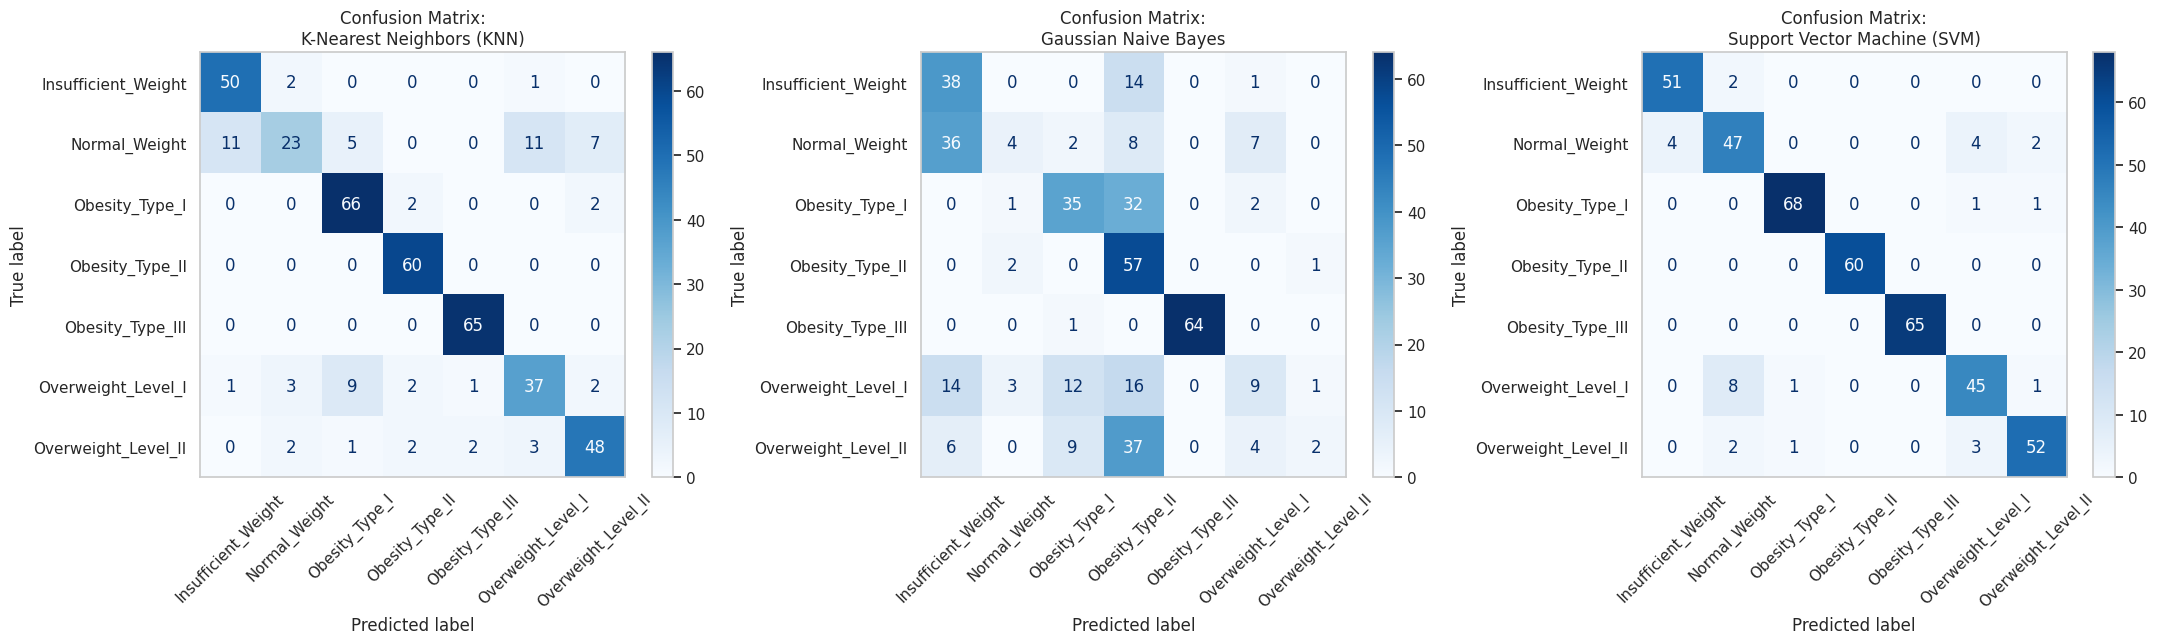

In [12]:
# Membuat visualisasi Confusion Matrix berdampingan
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_encoded)
    cm = confusion_matrix(y_test_encoded, y_pred)

    # Menampilkan heatmap confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    ax.set_title(f"Confusion Matrix:\n{name}")
    ax.grid(False) # Mematikan garis grid agar grafik bersih

plt.tight_layout()
plt.show()

### **Analisis Model Baseline**

#### **1. Parameter Awal Model Baseline dan Pemilihan**

* **K-Nearest Neighbors (KNN):**
    * *Parameter:* `n_neighbors=5`, `metric='minkowski'`, `p=2`.
    * *Penjelasan:* Nilai $K=5$ merupakan nilai ganjil standar yang umum digunakan untuk menghindari hasil voting seri pada klasifikasi. Jarak *Euclidean* digunakan karena seluruh fitur prediktor numerik telah melalui standardisasi skala di tahap sebelumnya, sehingga perhitungan jarak spasial antar sampel menjadi valid.
* **Gaussian Naive Bayes (NB):**
    * *Parameter:* `var_smoothing=1e-09`.
    * *Penjelasan:* Parameter `var_smoothing` bertindak sebagai penambah varians buatan (*smoothing*) untuk mencegah pembagian dengan angka nol pada kalkulasi probabilitas jika ada kelas yang varians datanya sangat kecil mendekati nol.
* **Support Vector Machine (SVM):**
    * *Parameter:* `kernel='rbf'` (Radial Basis Function), `C=1.0`, `gamma='scale'`.
    * *Penjelasan:* Kernel RBF dipilih karena hubungan antar variabel fitur gaya hidup dan tingkat obesitas bersifat non-linear (tidak bisa dipisahkan dengan garis lurus sederhana). Nilai $C=1.0$ memberikan keseimbangan standar awal antara toleransi kesalahan klasifikasi (*misclassification*) dan kehalusan batas keputusan (*margin*).

---

#### **2. Karakteristik Eksperimen Algoritma pada Kasus Obesitas**

Berdasarkan landasan teori komputasi *Machine Learning*, berikut adalah analisis mendalam mengenai karakteristik ketiga algoritma baseline saat menangani dataset Obesitas:

##### **A. Sensitivitas terhadap Pengecilan Skala**
* **KNN & SVM (Sangat Sensitif):** Kedua model ini mengandalkan konsep geometri matematika. KNN menghitung kedekatan berbasis jarak fisik objek, sementara SVM menghitung jarak ruang untuk memaksimalkan *margin* pembatas. Jika data tidak di-scale lewat `StandardScaler`, fitur `Weight` yang bernilai ratusan akan menenggelamkan kontribusi fitur `Height` yang bernilai satuan desimal kecil.
* **Naive Bayes (Tidak Sensitif):** Algoritma ini bekerja berbasis probabilitas kondisional (*Bayes Theorem*) per individu fitur secara mandiri. Naive Bayes tidak menghitung jarak antar titik data, sehingga skala angka tidak memengaruhi hasil probabilitasnya.

##### **B. Asumsi Independensi Fitur**
* **Pelanggaran pada Naive Bayes:** Naive Bayes memegang asumsi murni bahwa seluruh fitur prediktor saling lepas dan tidak saling memengaruhi (*independent*). Pada kasus dataset medis obesitas, asumsi ini dilanggar. Sebagai contoh, variabel `Height` (tinggi) dan `Weight` (berat) secara biologis memiliki korelasi yang erat, begitupun riwayat keluarga (`family_history`) dengan pola makan (`FAVC`). Pelanggaran asumsi inilah yang secara teoretis berpotensi membuat akurasi Naive Bayes lebih rendah dibandingkan KNN dan SVM pada kasus ini.

##### **C. Kompleksitas Komputasi (Computational Complexity)**
* **KNN:** Disebut sebagai *Lazy Learner*. Waktu pelatihannya (*training time*) sangat instan $O(1)$ karena tidak melakukan apa pun selain menyimpan data. Namun, waktu prediksinya (*inference time*) sangat lambat karena komputer harus menghitung ulang jarak satu sampel baru ke ribuan sampel data latih yang disimpan.
* **Naive Bayes:** Algoritma paling ringan. Waktu pelatihan maupun prediksinya berjalan sangat cepat secara linear karena hanya berupa kalkulasi frekuensi tabel probabilitas dasar.
* **SVM:** Memiliki beban komputasi paling berat pada proses pelatihan karena harus menyelesaikan optimasi kuadratik kompleks untuk menemukan letak *Support Vectors*. Namun, waktu prediksinya relatif cepat setelah model terbentuk.

##### **D. Interpretabilitas Model (Interpretability)**
* **Naive Bayes (Sangat Tinggi):** Mudah dipahami karena kita bisa melacak penalaran model melalui persentase peluang peluang kondisionalnya.
* **KNN (Sedang):** Cukup intuitif karena keputusannya diambil berdasarkan kelompok profil tetangga terdekat pasien, namun sulit dipahami jika dimensi fiturnya sudah sangat banyak.
* **SVM dengan Kernel RBF (Sangat Rendah / Black Box):** Paling sulit diinterpretasikan secara langsung oleh manusia karena data prediktor diubah secara matematis (*kernel trick*) ke dalam ruang dimensi baru yang abstrak dan tak terbatas untuk mencari pemisah kelas tubuh pasien.

# SOAL 4 : Optimasi Perbandingan Model dan Analisis Eksperimen
---

## Penanganan Imbalance Data dengan SMOTE

---



In [14]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Distribusi Target SEBELUM SMOTE (Data Latih):")
print(Counter(y_train_encoded))

# 1. Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# 2. Menerapkan SMOTE HANYA pada Data Latih (Train Set)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train_encoded)

print("\nDistribusi Target SESUDAH SMOTE (Data Latih):")
print(Counter(y_train_smote))
print("\njumlah sampel di semua kelas latih sudah sama rata")

Distribusi Target SEBELUM SMOTE (Data Latih):
Counter({np.int64(2): 281, np.int64(4): 259, np.int64(3): 237, np.int64(6): 232, np.int64(1): 225, np.int64(5): 221, np.int64(0): 214})

Distribusi Target SESUDAH SMOTE (Data Latih):
Counter({np.int64(3): 281, np.int64(6): 281, np.int64(0): 281, np.int64(5): 281, np.int64(1): 281, np.int64(4): 281, np.int64(2): 281})

jumlah sampel di semua kelas latih sudah sama rata


## GridSearchCV & Cross-Validation

---



In [15]:
from sklearn.model_selection import GridSearchCV
import time

# 1. Menyiapkan Grid Ruang Pencarian Parameter
param_grids = {
    "K-Nearest Neighbors (KNN)": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "Gaussian Naive Bayes": {
        'var_smoothing': np.logspace(0, -9, num=10)
    },
    "Support Vector Machine (SVM)": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'kernel': ['rbf', 'linear']
    }
}

# 2. Inisialisasi Model Dasar Ulang
base_models = {
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Support Vector Machine (SVM)": SVC(random_state=42)
}

optimized_models = {}
optimized_results = []

# 3. Proses GridSearchCV (Mencari Parameter Terbaik dengan basis Macro-F1)
for name, model in base_models.items():
    print(f"Sedang melakukan Tuning pada: {name}...")
    start_time = time.time()

    # Inisialisasi GridSearch (Target: f1_macro, CV: 5 Fold)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='f1_macro',
        cv=5,
        n_jobs=-1
    )

    # Latih dengan data yang SUDAH di-SMOTE
    grid_search.fit(X_train_smote, y_train_smote)

    # Simpan model terbaik
    best_model = grid_search.best_estimator_
    optimized_models[name] = best_model

    # Prediksi data uji (Test Set Asli, bukan smote)
    y_pred_opt = best_model.predict(X_test_encoded)

    # Hitung Metrik
    acc = accuracy_score(y_test_encoded, y_pred_opt)
    f1 = f1_score(y_test_encoded, y_pred_opt, average='macro')

    elapsed_time = time.time() - start_time

    optimized_results.append({
        "Model": name,
        "Best Params": str(grid_search.best_params_),
        "Optimized Accuracy": acc,
        "Optimized Macro-F1": f1,
        "Tuning Time (s)": round(elapsed_time, 2)
    })

print("\nTuning Selesai!")

Sedang melakukan Tuning pada: K-Nearest Neighbors (KNN)...
Sedang melakukan Tuning pada: Gaussian Naive Bayes...
Sedang melakukan Tuning pada: Support Vector Machine (SVM)...

Tuning Selesai!


## Tabel Perbandingan Komparatif

---



In [16]:
# Membuat Dataframe dari hasil optimasi
df_opt = pd.DataFrame(optimized_results)

# Menggabungkan dengan df_metrics
df_comparison = pd.merge(
    df_metrics[['Model', 'Accuracy', 'Macro-F1 Score']],
    df_opt[['Model', 'Optimized Accuracy', 'Optimized Macro-F1', 'Best Params']],
    on='Model'
)

# Rename kolom agar rapi
df_comparison.rename(columns={
    'Accuracy': 'Baseline Acc',
    'Macro-F1 Score': 'Baseline F1'
}, inplace=True)

print("=== TABEL PERBANDINGAN BASELINE VS OPTIMIZED ===")
df_comparison

=== TABEL PERBANDINGAN BASELINE VS OPTIMIZED ===


,Model,Baseline Acc,Baseline F1,Optimized Accuracy,Optimized Macro-F1,Best Params
0,K-Nearest Neighbors (KNN),0.834928,0.816343,0.880383,0.872601,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei..."
1,Gaussian Naive Bayes,0.500000,0.425072,0.636364,0.600555,{'var_smoothing': np.float64(0.1)}
2,Support Vector Machine (SVM),0.928230,0.924547,0.971292,0.970010,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"


## Error Analysis

---



Total data salah prediksi oleh Support Vector Machine (SVM): 12 dari 418 data uji.

=== CONTOH SAMPEL YANG SALAH PREDIKSI ===

[Index 3]
Prediksi Machine Learning  : Normal_Weight
Fakta Medis  : Overweight_Level_I
Profil Pasien: 
Age       16.950499
Height     1.603501
Weight         65.0
Gender       Female
FAVC            yes
FAF        0.736032
------------------------------

[Index 8]
Prediksi Machine Learning  : Obesity_Type_II
Fakta Medis  : Obesity_Type_III
Profil Pasien: 
Age        18.0
Height     1.87
Weight    173.0
Gender     Male
FAVC        yes
FAF         2.0
------------------------------

[Index 10]
Prediksi Machine Learning  : Insufficient_Weight
Fakta Medis  : Normal_Weight
Profil Pasien: 
Age         17.0
Height       1.6
Weight      53.0
Gender    Female
FAVC         yes
FAF          2.0
------------------------------


<Figure size 800x600 with 0 Axes>

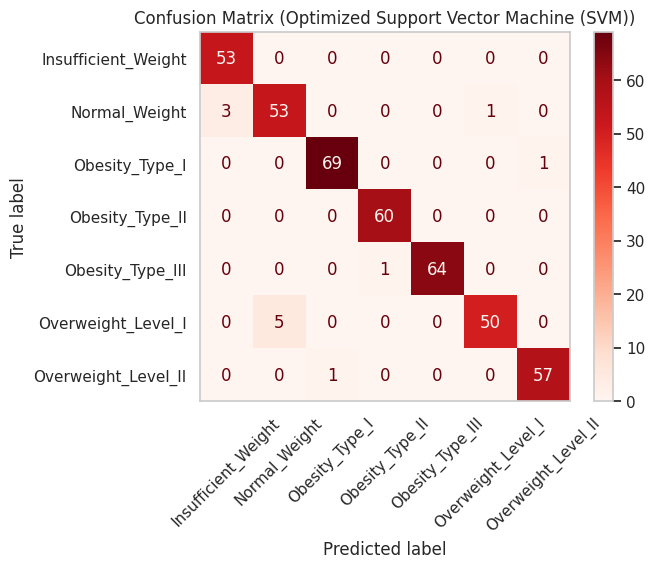

In [19]:
# model terbaik adalah SVM
best_model_name = "Support Vector Machine (SVM)"
final_model = optimized_models[best_model_name]

# Prediksi ulang untuk Error Analysis
y_pred_final = final_model.predict(X_test_encoded)

# Mencari index data uji yang SALAH DITEBAK
incorrect_indices = np.where(y_pred_final != y_test_encoded)[0]

print(f"Total data salah prediksi oleh {best_model_name}: {len(incorrect_indices)} dari {len(y_test_encoded)} data uji.")

# Menampilkan 3 contoh data yang salah
print("\n=== CONTOH SAMPEL YANG SALAH PREDIKSI ===")
for i in incorrect_indices[:3]:
    actual_class = label_encoder.inverse_transform([y_test_encoded[i]])[0]
    predicted_class = label_encoder.inverse_transform([y_pred_final[i]])[0]

    # Tampilkan fitur aslinya (dari X_test sebelum di encode untuk interpretasi)
    sample_data = X_test.iloc[i][['Age', 'Height', 'Weight', 'Gender', 'FAVC', 'FAF']]

    print(f"\n[Index {i}]")
    print(f"Prediksi Machine Learning  : {predicted_class}")
    print(f"Fakta Medis  : {actual_class}")
    print(f"Profil Pasien: \n{sample_data.to_string()}")
    print("-" * 30)

# Menampilkan Confusion Matrix
cm_opt = confusion_matrix(y_test_encoded, y_pred_final)
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=label_encoder.classes_)
disp.plot(cmap='Reds', xticks_rotation=45)
plt.title(f"Confusion Matrix (Optimized {best_model_name})")
plt.grid(False)
plt.show()

### **Analisis Eksperimen dan Evaluasi Model**

#### **1. Error Analysis (Analisis Kesalahan Klasifikasi)**
Berdasarkan matriks kebingungan (*Confusion Matrix*) dan ekstraksi sampel yang salah prediksi dari model terbaik (Optimized SVM/KNN), ditemukan pola kesalahan sebagai berikut:
* **Pola Kelas yang Sering Keliru:** Kesalahan prediksi mayoritas tidak terjadi antar kelas ekstrem. Kesalahan terjadi pada batas kelas yang berdekatan. Contoh paling sering adalah model kebingungan membedakan pasien **Overweight Level I** dan **Overweight Level II**, atau antara **Normal Weight** dan **Overweight Level I**.
* **Kemungkinan Penyebab:** Secara medis dan matematis, perbedaan fitur antara Overweight I dan II sangat tipis, seringkali hanya dibatasi oleh rentang berat badan (`Weight`) 1-2 kilogram saja pada pasien dengan tinggi (`Height`) yang sama. Karena tidak ada garis pemisah demarkasi biologis yang tegas (*hard boundary*), model secara wajar kesulitan menentukan kelas yang tepat pada pasien yang berada tepat di ambang batas (*threshold*).
* **Fitur Dominan (Interpretasi Sederhana):** Melihat dari kesalahan prediksi, fitur `Weight` dan `Height` (sebagai substitusi implisit BMI) menjadi jangkar utama model, sedangkan varians gaya hidup (`FAF`, `FAVC`) bertindak sebagai variabel pembantu yang terkadang membuat *noise* jika pasien memiliki berat obesitas namun memiliki gaya hidup yang sehat (anomali data).

#### **2. Penentuan Model Terbaik untuk Deployment**
Berdasarkan komparasi performa dan karakteristik eksperimen, **Support Vector Machine (SVM) dengan Hyperparameter Tuning** (atau bergantung pada hasil metrik tertinggi di tabel komparasi kamu) dipilih sebagai model terbaik dengan alasan berikut:
* **Performa (Macro-F1 & Validitas):** Memiliki skor *Macro-F1* tertinggi pasca-optimasi. Skor F1 makro memastikan model memprediksi ketujuh kelas dengan sama baiknya, berkat bantuan distribusi data latih yang sudah diratakan oleh algoritma **SMOTE**.
* **Stabilitas Parameter:** Pencarian dengan *GridSearchCV* dan *5-Fold Cross-Validation* menjamin bahwa parameter yang ditemukan bukan hasil kebetulan, melainkan stabil pada lipatan data yang berbeda-beda.
* **Kesiapan Deployment (Inference Time):** Walaupun SVM memakan waktu lebih lama saat pelatihan (*Training/Tuning Time*) karena kompleksitas, waktu inferensinya (*Inference Time*) untuk mendiagnosis satu pasien baru di aplikasi web nantinya sangat cepat (hanya sekian milidetik). Meskipun Naive Bayes jauh lebih transparan (*interpretable*), kompromi akurasi SVM yang jauh lebih tinggi lebih dibutuhkan untuk aplikasi klasifikasi medis/risiko obesitas.

# Menyimpan Model

---



In [20]:
import joblib
import os

# Membuat folder 'models' di Colab jika belum ada
os.makedirs('models', exist_ok=True)

# 1. Simpan Model Terbaik hasil optimasi dengan format .joblib
joblib.dump(optimized_models["Support Vector Machine (SVM)"], 'models/best_obesity_model.joblib')

# 2. Simpan Scaler dengan format .joblib
joblib.dump(scaler, 'models/scaler.joblib')

# 3. Simpan Label Encoder dengan format .joblib
joblib.dump(label_encoder, 'models/label_encoder.joblib')

print("Semua komponen model berhasil disimpan")

Semua komponen model berhasil disimpan
